# Aurora SIGER — Fase 2: Pouso e Estabilização (MGPEB)

**Módulo de Gerenciamento de Pouso e Estabilização de Base** — sistema embarcado responsável por organizar o pouso dos doze módulos pré-fabricados que constituem a primeira colônia humana em Marte, na missão **Aurora Siger**.

Este notebook acompanha o relatório técnico ([`relatorio.pdf`](relatorio.pdf)) com uma abordagem **executável e visual**: cada conceito é demonstrado com código rodando sobre o pacote `aurora_siger.landing`, e cada função física aparece como gráfico em vez de tabela ASCII. Para uma exploração interativa em terminal, use o protótipo CLI:

```bash
python3 fases/fase-2/mgpeb.py
```

**Estrutura do notebook:**

1. Setup e os doze módulos da colônia
2. Estruturas lineares — `Vector`, `Queue`, `Stack`
3. Regra booleana de autorização — `F ∧ A ∧ (L ∨ E) ∧ S`
4. Cenários comparados — atmosfera ideal, atmosfera ruim, zona ocupada
5. Modelagem física do pouso — quatro funções, quatro gráficos
6. O que se aprendeu

Os ensaios que contextualizam o sistema (evolução do hardware embarcado, ESG da colônia) vivem em [`docs/fase-2/`](../../docs/fase-2/).

## 1. Setup e os doze módulos da colônia

Toda a lógica do MGPEB vive em `aurora_siger.landing`. Importamos as peças que vamos usar e fixamos uma semente aleatória para que os cenários deste notebook sejam reproduzíveis.

In [1]:
import random
import math
import matplotlib.pyplot as plt

from aurora_siger.landing import (
    LandingMission, Module, Vector, Queue, Stack,
    evaluate, AuthorizationResult, Alert,
    descent_altitude, fuel_consumption, solar_energy, surface_temperature,
    DEFAULT_MODULES, FUEL_THRESHOLD, EMERGENCY_CRITICALITY, MISSION_START_HOUR,
)

random.seed(2026)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

A frota canônica é uma lista de doze instâncias de `Module` declaradas em `aurora_siger.landing.module`. Os atributos *estáticos* (id, nome, tipo, prioridade, criticidade da carga, massa) são fixos. Os *voláteis* (combustível, distância, velocidade, sensores) são reseeded a cada execução por `Module.randomize()`.

In [2]:
print(f"Total de módulos: {len(DEFAULT_MODULES)}\n")
print(f"{'ID':>3}  {'Nome':<28} {'Tipo':<14} {'Prio':>4} {'Crít':>4} {'Massa (kg)':>12}")
print("-" * 72)
for m in DEFAULT_MODULES:
    print(f"{m.id:>3}  {m.name:<28} {m.type:<14} {m.priority:>4} {m.cargo_criticality:>4} {m.mass:>12,.0f}")

Total de módulos: 12

 ID  Nome                         Tipo           Prio Crít   Massa (kg)
------------------------------------------------------------------------
  1  Comando e Controle           command           1    5       12,000
  2  Suporte de Vida (ECLSS)      life_support      2    5       15,000
  3  Habitação                    habitat           3    4       18,000
  4  Energia Solar                solar             4    5        8,000
  5  Energia Nuclear              nuclear           5    5       22,000
  6  Comunicações                 comms             6    4        6,000
  7  Suporte Médico               medical           7    4       10,000
  8  Produção de Alimentos        food              8    3       14,000
  9  Logística e Armazenamento    logistics         9    3       25,000
 10  ISRU (Recursos Locais)       isru             10    2       20,000
 11  Oficina e Manutenção         workshop         11    2       16,000
 12  Laboratório Científico       lab    

**Note a ordem de prioridade**: comando e suporte de vida (ECLSS) descem primeiro; habitação, energia (solar e nuclear) e comunicações em seguida; científicos por último. Essa ordem é uma **constituição operacional** — codifica a hierarquia de valores da colônia (ver Seção 6 do relatório, sobre ESG).

A **criticidade da carga** é independente: módulos com `cargo_criticality == 5` são *emergências* — se algo der errado, eles têm permissão de descer mesmo com a zona ocupada.

## 2. Estruturas lineares — `Vector`, `Queue`, `Stack`

O MGPEB organiza seu estado em quatro estruturas lineares, cada uma escolhida pelo invariante de acesso adequado à sua função:

| Estrutura | Disciplina | Papel |
|---|---|---|
| `landing_queue` | FIFO (`Queue`) | Módulos aguardando autorização |
| `landed_modules` | índice livre (`Vector`) | Registro dos módulos pousados |
| `waiting_modules` | índice livre (`Vector`) | Registro dos módulos adiados |
| `alert_stack` | LIFO (`Stack`) | Alertas de bloqueio (mais recente no topo) |

Todas as três classes herdam busca linear e ordenação de `Vector`, espelhando a Figura A.1 do relatório.

In [3]:
# Demonstração rápida das três disciplinas de acesso.
fila = Queue()
for nome in ["A", "B", "C"]:
    fila.enqueue(nome)
print(f"Queue (FIFO):    enqueue A, B, C  →  dequeue →  {fila.dequeue()}, {fila.dequeue()}, {fila.dequeue()}")

pilha = Stack()
for nome in ["A", "B", "C"]:
    pilha.push(nome)
print(f"Stack (LIFO):    push A, B, C     →  pop     →  {pilha.pop()}, {pilha.pop()}, {pilha.pop()}")

vetor = Vector()
for nome in ["A", "B", "C"]:
    vetor.append(nome)
vetor.insert(1, "X")
print(f"Vector (livre):  append + insert  →  {vetor.to_list()}")

Queue (FIFO):    enqueue A, B, C  →  dequeue →  A, B, C
Stack (LIFO):    push A, B, C     →  pop     →  C, B, A
Vector (livre):  append + insert  →  ['A', 'X', 'B', 'C']


### Ordenação multi-critério da fila de pouso

A política natural FIFO é reordenada antes da simulação por uma chave composta — **ETA → prioridade → combustível**. ETA é discretizado em horas cheias (`ceil(distance / speed)`), o que produz empates frequentes; os critérios secundários decidem o desempate. O combustível entra como último critério porque o módulo mais quase-no-limite tem urgência se tudo o mais empata.

In [4]:
mission = LandingMission.from_defaults()
mission.randomize_scenario()

print("Antes da ordenação (ordem de chegada):")
for m in list(mission.landing_queue)[:6]:
    print(f"  {m.name:<28} ETA={m.eta_str}  prio={m.priority:>2}  fuel={m.fuel_level:>5.1f}%")

mission.landing_queue.sort_multi()

print("\nDepois de sort_multi() (ETA → prioridade → combustível):")
for m in list(mission.landing_queue)[:6]:
    print(f"  {m.name:<28} ETA={m.eta_str}  prio={m.priority:>2}  fuel={m.fuel_level:>5.1f}%")

Antes da ordenação (ordem de chegada):
  Comando e Controle           ETA=08:00  prio= 1  fuel= 24.5%
  Suporte de Vida (ECLSS)      ETA=09:00  prio= 2  fuel= 23.2%
  Habitação                    ETA=08:00  prio= 3  fuel= 77.7%
  Energia Solar                ETA=08:00  prio= 4  fuel= 75.1%
  Energia Nuclear              ETA=08:00  prio= 5  fuel= 23.9%
  Comunicações                 ETA=08:00  prio= 6  fuel= 69.8%

Depois de sort_multi() (ETA → prioridade → combustível):
  Comando e Controle           ETA=08:00  prio= 1  fuel= 24.5%
  Habitação                    ETA=08:00  prio= 3  fuel= 77.7%
  Energia Solar                ETA=08:00  prio= 4  fuel= 75.1%
  Energia Nuclear              ETA=08:00  prio= 5  fuel= 23.9%
  Comunicações                 ETA=08:00  prio= 6  fuel= 69.8%
  Suporte Médico               ETA=08:00  prio= 7  fuel= 93.4%


## 3. Regra booleana de autorização

O coração inspecionável do MGPEB. A função `evaluate()` é **pura**: recebe um módulo e um dicionário de condições ambientais, devolve um `AuthorizationResult` com o veredito booleano e a lista ordenada de motivos de falha. Sem efeitos colaterais, sem prints, sem estado global — exatamente para que possa ser auditada por tabela-verdade.

$$\text{AUTORIZADO} = F \wedge A \wedge (L \vee E) \wedge S$$

| Símbolo | Variável | Origem |
|:---:|:---|:---|
| **F** | `fuel_ok` | `module.fuel_level >= 20` |
| **A** | `atmosphere_ok` | condição ambiental |
| **L** | `zone_free` | condição ambiental |
| **E** | `emergency` | `module.cargo_criticality == 5` — *bypass* da zona ocupada |
| **S** | `sensors_ok` | `module.sensors_ok` |

A subexpressão `(L ∨ E)` é o ponto sutil: módulos críticos (suporte de vida, comando, geração de energia) descem mesmo se a zona estiver ocupada — o custo de adiar supera o de aceitar a sobreposição.

In [5]:
# Confirma o bypass de emergência: módulo crítico desce com zona ocupada.
modulo_critico = next(m.copy() for m in DEFAULT_MODULES if m.cargo_criticality == 5)
modulo_normal  = next(m.copy() for m in DEFAULT_MODULES if m.cargo_criticality < 5)

condicoes_zona_ocupada = {"atmosphere_ok": True, "landing_zone_free": False}

r_critico = evaluate(modulo_critico, condicoes_zona_ocupada)
r_normal  = evaluate(modulo_normal,  condicoes_zona_ocupada)

print(f"{modulo_critico.name:<30}  crítico={modulo_critico.cargo_criticality}  →  AUTORIZADO={r_critico.authorized}")
print(f"{modulo_normal.name:<30}  crítico={modulo_normal.cargo_criticality}  →  AUTORIZADO={r_normal.authorized}")
print(f"\nMotivo do bloqueio do módulo normal: {r_normal.reasons}")

Comando e Controle              crítico=5  →  AUTORIZADO=True
Habitação                       crítico=4  →  AUTORIZADO=False

Motivo do bloqueio do módulo normal: ['Zona de pouso ocupada']


### Tabela-verdade da subexpressão crítica `L ∨ E`

A única subexpressão não trivial da regra. Mostra que **a zona ocupada só bloqueia módulos não críticos**.

In [6]:
print(f"{'L (zona livre)':<18} {'E (emergência)':<18} {'L ∨ E':<10}  AUTORIZADO se F=A=S=True")
print("-" * 80)
for L in (False, True):
    for E in (False, True):
        # F=A=S=True → resultado depende só de (L ∨ E)
        modulo = Module(
            id=99, name="probe", type="lab", priority=5,
            fuel_level=80.0, mass=1000.0,
            cargo_criticality=EMERGENCY_CRITICALITY if E else 2,
            distance=400.0, speed=200.0, sensors_ok=True,
        )
        cond = {"atmosphere_ok": True, "landing_zone_free": L}
        r = evaluate(modulo, cond)
        print(f"{str(L):<18} {str(E):<18} {str(L or E):<10}  {r.authorized}")

L (zona livre)     E (emergência)     L ∨ E       AUTORIZADO se F=A=S=True
--------------------------------------------------------------------------------
False              False              False       False
False              True               True        True
True               False              True        True
True               True               True        True


## 4. Cenários comparados

A `LandingMission` orquestra a fila, a regra e o registro de alertas. `simulate()` é o método que dispara a operação completa e devolve um `SimulationReport` com `landed`, `waiting` e `alerts`. Comparamos quatro cenários diferentes — todos com a mesma frota, mas condições distintas.

In [7]:
def rodar_cenario(nome: str, conditions: dict, randomize: bool = False, seed: int = 0) -> dict:
    """Executa uma simulação e devolve um sumário em dict."""
    if randomize:
        random.seed(seed)
    mission = LandingMission(
        modules=(m.copy() for m in DEFAULT_MODULES),
        conditions=dict(conditions),
    )
    if randomize:
        mission.randomize_scenario()
    report = mission.simulate()
    return {
        "nome": nome,
        "landed": len(report.landed),
        "waiting": len(report.waiting),
        "alerts": len(report.alerts),
        "report": report,
        "mission": mission,
    }

cenarios = [
    rodar_cenario("A — Tudo OK (defaults)",      {"atmosphere_ok": True,  "landing_zone_free": True}),
    rodar_cenario("B — Atmosfera ruim",           {"atmosphere_ok": False, "landing_zone_free": True}),
    rodar_cenario("C — Zona ocupada (testa bypass)", {"atmosphere_ok": True,  "landing_zone_free": False}),
    rodar_cenario("D — Aleatório (seed=2026)",    {"atmosphere_ok": True,  "landing_zone_free": True}, randomize=True, seed=2026),
]

print(f"{'Cenário':<35} {'Pousados':>10} {'Em espera':>10} {'Alertas':>9}")
print("-" * 70)
for c in cenarios:
    print(f"{c['nome']:<35} {c['landed']:>10} {c['waiting']:>10} {c['alerts']:>9}")

Cenário                               Pousados  Em espera   Alertas
----------------------------------------------------------------------
A — Tudo OK (defaults)                      12          0         0
B — Atmosfera ruim                           0         12        12
C — Zona ocupada (testa bypass)              4          8         8
D — Aleatório (seed=2026)                    4          8         8


### Visualização: barras de pousados vs em espera por cenário

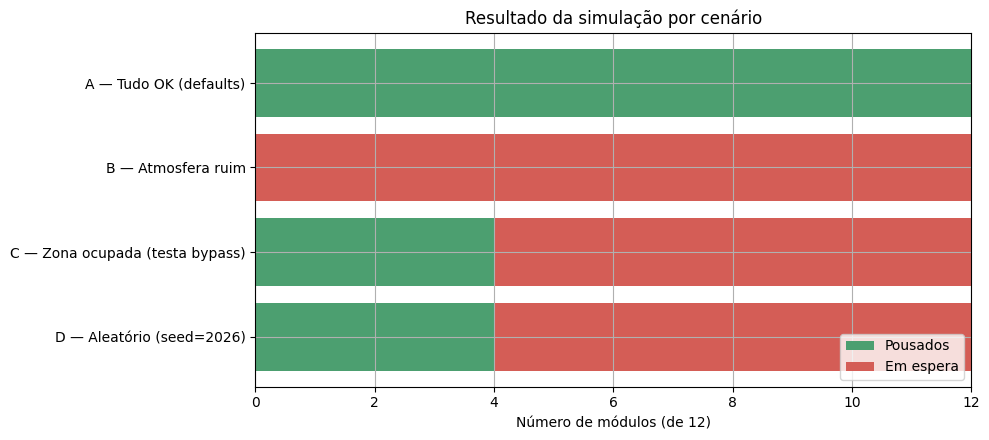

In [8]:
nomes = [c["nome"] for c in cenarios]
landed = [c["landed"] for c in cenarios]
waiting = [c["waiting"] for c in cenarios]

fig, ax = plt.subplots(figsize=(10, 4.5))
y = range(len(nomes))
ax.barh(y, landed,  color="#4C9F70", label="Pousados")
ax.barh(y, waiting, left=landed, color="#D45D56", label="Em espera")
ax.set_yticks(list(y))
ax.set_yticklabels(nomes)
ax.set_xlabel("Número de módulos (de 12)")
ax.set_title("Resultado da simulação por cenário")
ax.legend(loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Inspeção do cenário C — bypass de emergência

No cenário com **zona ocupada**, esperamos que apenas módulos com `cargo_criticality == 5` desçam. Vamos checar.

In [9]:
cenario_c = cenarios[2]
print("Pousados (esperamos só os de criticidade 5):")
for m in cenario_c["report"].landed:
    print(f"  {m.name:<28}  criticidade={m.cargo_criticality}")

print("\nEm espera (esperamos os não-críticos):")
for m in cenario_c["report"].waiting:
    print(f"  {m.name:<28}  criticidade={m.cargo_criticality}")

Pousados (esperamos só os de criticidade 5):
  Comando e Controle            criticidade=5
  Suporte de Vida (ECLSS)       criticidade=5
  Energia Solar                 criticidade=5
  Energia Nuclear               criticidade=5

Em espera (esperamos os não-críticos):
  Comunicações                  criticidade=4
  Habitação                     criticidade=4
  Suporte Médico                criticidade=4
  Produção de Alimentos         criticidade=3
  Logística e Armazenamento     criticidade=3
  Laboratório Científico        criticidade=2
  Oficina e Manutenção          criticidade=2
  ISRU (Recursos Locais)        criticidade=2


A separação é nítida: criticidade 5 passa, demais ficam aguardando. A pilha de alertas registra cada bloqueio em ordem LIFO — o operador inspeciona primeiro os mais recentes.

In [10]:
print(f"Pilha de alertas do cenário C ({cenario_c['mission'].alert_stack.size()} alertas):")
print()
stack = cenario_c["mission"].alert_stack
for i in range(stack.size() - 1, -1, -1):
    a = stack[i]
    posicao = stack.size() - i
    print(f"  [{posicao}] {a.module_name:<28}  ETA {a.timestamp}  →  {a.reason}")

Pilha de alertas do cenário C (8 alertas):

  [1] ISRU (Recursos Locais)        ETA 12:00  →  Zona de pouso ocupada
  [2] Oficina e Manutenção          ETA 11:00  →  Zona de pouso ocupada
  [3] Laboratório Científico        ETA 10:00  →  Zona de pouso ocupada
  [4] Logística e Armazenamento     ETA 10:00  →  Zona de pouso ocupada
  [5] Produção de Alimentos         ETA 10:00  →  Zona de pouso ocupada
  [6] Suporte Médico                ETA 08:00  →  Zona de pouso ocupada
  [7] Habitação                     ETA 08:00  →  Zona de pouso ocupada
  [8] Comunicações                  ETA 07:00  →  Zona de pouso ocupada


## 5. Modelagem física do pouso

Quatro funções elementares modelam fenômenos relevantes da descida e da operação na superfície marciana. São puras, sem dependências externas, e estão em `aurora_siger.landing.physics`.

### 5.1 Altitude de descida (queda livre)

$$h(t) = h_0 - v_0 \cdot t - \tfrac{1}{2} a \cdot t^2$$

Modelo da fase **antes** dos retrofoguetes — gravidade marciana ($a = 3{,}7$ m/s²) puxa o módulo para baixo. O impacto ocorre quando $h(t) = 0$.

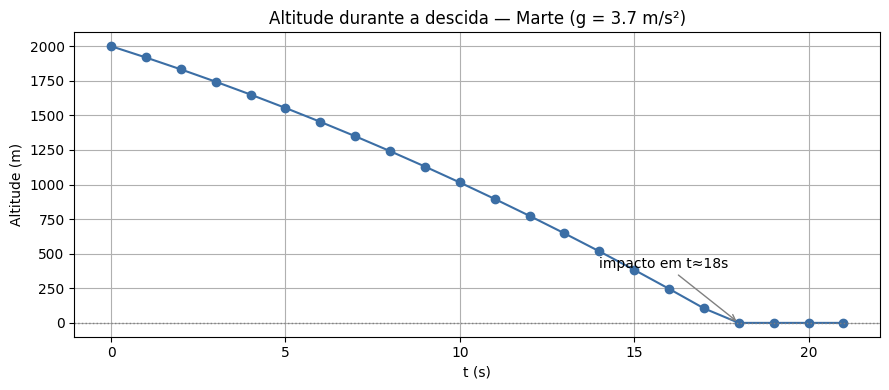

In [11]:
ts = list(range(0, 22))
hs = [descent_altitude(t) for t in ts]

fig, ax = plt.subplots()
ax.plot(ts, hs, marker="o", color="#3B6EA5")
ax.axhline(0, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel("t (s)")
ax.set_ylabel("Altitude (m)")
ax.set_title("Altitude durante a descida — Marte (g = 3.7 m/s²)")

t_impacto = next(t for t, h in zip(ts, hs) if h == 0)
ax.annotate(f"impacto em t≈{t_impacto}s",
            xy=(t_impacto, 0), xytext=(t_impacto - 4, 400),
            arrowprops=dict(arrowstyle="->", color="grey"))
plt.tight_layout()
plt.show()

### 5.2 Consumo de combustível (exponencial)

$$C(v) = C_0 \cdot e^{k \cdot v}$$

Frenagem brusca consome **exponencialmente** mais combustível que frenagem gradual. É a razão pela qual módulos pesados precisam aproximação suave.

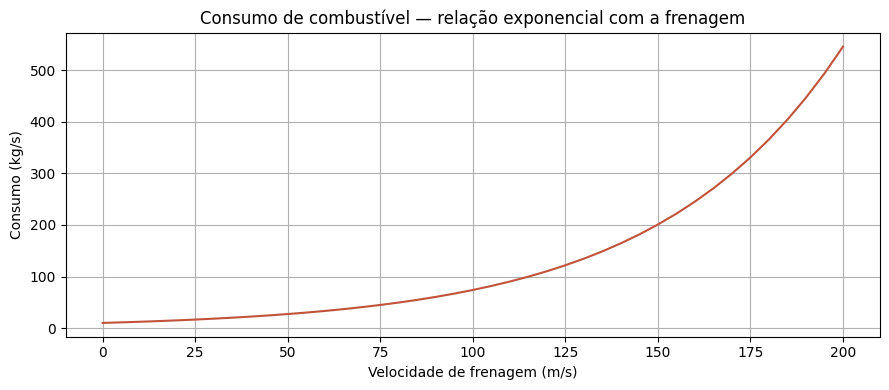

In [12]:
vs = list(range(0, 201, 5))
cs = [fuel_consumption(v) for v in vs]

fig, ax = plt.subplots()
ax.plot(vs, cs, color="#C0533A")
ax.set_xlabel("Velocidade de frenagem (m/s)")
ax.set_ylabel("Consumo (kg/s)")
ax.set_title("Consumo de combustível — relação exponencial com a frenagem")
plt.tight_layout()
plt.show()

### 5.3 Energia solar (parábola invertida)

$$E(t) = -a \cdot (t - t_{\text{meio}})^2 + E_{\max}$$

Pico ao **meio-dia marciano** ($t_{\text{meio}} = 12{,}3$ h), zero no nascer e pôr do sol. Geração máxima em torno de 2200 W. O modelo ignora ângulo de inclinação dos painéis e tempestades de poeira — fatores discutidos na Seção 6 do relatório (ESG).

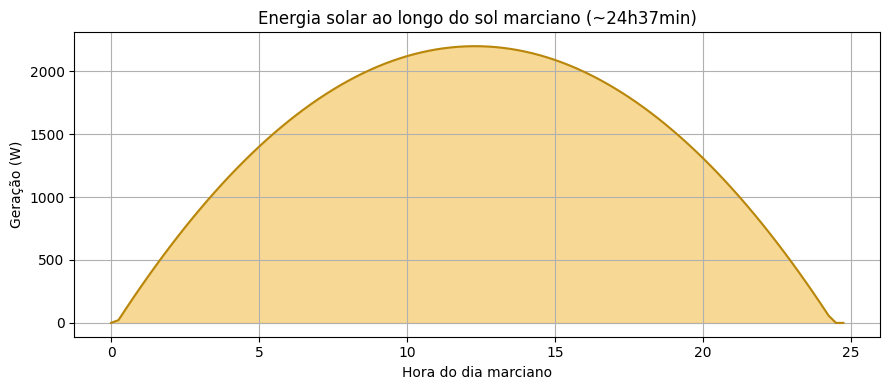

In [13]:
ts = [t / 4 for t in range(0, 100)]  # 0..25 h em passos de 0.25
es = [solar_energy(t) for t in ts]

fig, ax = plt.subplots()
ax.fill_between(ts, es, color="#F2C14E", alpha=0.6)
ax.plot(ts, es, color="#B8860B")
ax.set_xlabel("Hora do dia marciano")
ax.set_ylabel("Geração (W)")
ax.set_title("Energia solar ao longo do sol marciano (~24h37min)")
plt.tight_layout()
plt.show()

### 5.4 Temperatura superficial (senoidal)

$$T(t) = T_{\text{média}} + A \cdot \sin(2\pi t / P - \varphi)$$

Variação senoidal com período de um sol (~24h37min). Média de **−60 °C** com amplitude de **40 °C** — a superfície marciana oscila entre cerca de −100 °C de madrugada e −20 °C ao meio-dia.

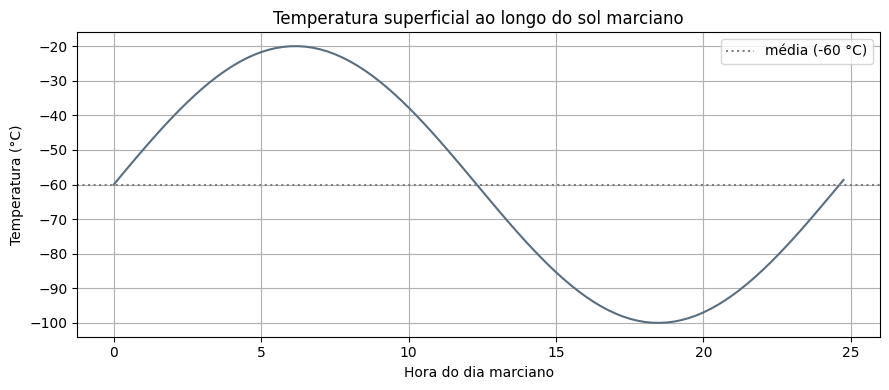

In [14]:
ts = [t / 4 for t in range(0, 100)]
temps = [surface_temperature(t) for t in ts]

fig, ax = plt.subplots()
ax.plot(ts, temps, color="#5B6E7E")
ax.axhline(-60, color="grey", linestyle=":", label="média (-60 °C)")
ax.set_xlabel("Hora do dia marciano")
ax.set_ylabel("Temperatura (°C)")
ax.set_title("Temperatura superficial ao longo do sol marciano")
ax.legend()
plt.tight_layout()
plt.show()

## 6. O que se aprendeu

Este protótipo articula três decisões que, juntas, são o argumento central da fase 2 — e que reaparecem nos ensaios de [`docs/fase-2/`](../../docs/fase-2/):

1. **Estruturas previsíveis vencem estruturas rápidas** quando o custo de falha é catastrófico. Bubble e Selection sort sobre 12 elementos têm pior caso O(n²) — irrelevante a essa escala — e oferecem em troca comportamento *inspecionável* a olho. Em sistemas críticos, o tempo de pior caso pequeno e fixo vale mais que o tempo médio menor.
2. **A regra booleana é o ponto onde a inspecionabilidade vira tangível**. `evaluate()` cabe em uma tabela-verdade de 32 linhas e pode ser auditada sem rodar o programa. Substituí-la por um classificador opaco — mesmo "mais preciso" — destruiria essa propriedade. Modelos probabilísticos têm lugar em **percepção** (sensores, diagnóstico), não em **decisão final**.
3. **O registro persistente é pré-condição para automação ética**. A `alert_stack` em LIFO não é só elegância de TAD — é o substrato sobre o qual auditoria, revisão e responsabilização se tornam possíveis. Sistemas que decidem sem registrar decidem para sempre sem prestar contas.

A continuidade entre este protótipo em Python e um sistema *flight-ready* embarcado em Marte não é transplantar código de uma linguagem para outra — é preservar a especificação funcional sob nova implementação verificada. A leitura da [contextualização histórica](../../docs/fase-2/contextualizacao-historica.md) detalha por que essa distinção importa.

---

**Para explorar interativamente**: `python3 fases/fase-2/mgpeb.py`
**Para a especificação completa**: [`relatorio.pdf`](relatorio.pdf)
**Para os ensaios**: [`docs/fase-2/`](../../docs/fase-2/)